# N2 · action chunking 消融: 平滑 vs 反应性

> 配套 11.3-L3 · action chunking = 一次预测 H 步动作 (开环执行再重规划)。
> 消融 chunk 大小, 量「没有免费的 chunk」: chunk ↑ → 块内更连贯, 但开环执行失去闭环纠错 →
> 反应性↓ (成功率可能掉)。这是 chunking 的核心权衡 (接 9.4 实验设计)。

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import diffusion_policy as dp
import numpy as np, torch
print('就绪')

就绪


## 1. 训练不同 chunk 大小的扩散动作头

In [2]:
torch.manual_seed(0)
CHUNKS = [1, 2, 4, 8]
models = {}
for ch in CHUNKS:
    S, A = dp.make_obstacle_demos(n=300, chunk=ch, seed=0)
    m = dp.build_diffusion_policy(chunk=ch)
    _, sc = dp.train_diffusion_policy(m, S, A, epochs=600)
    models[ch] = (m, sc)
    print(f'chunk={ch} 训练完毕 (动作块维度 {ch*dp.ACT_DIM})')

chunk=1 训练完毕 (动作块维度 2)


chunk=2 训练完毕 (动作块维度 4)


chunk=4 训练完毕 (动作块维度 8)


chunk=8 训练完毕 (动作块维度 16)


## 2. 量化: chunk vs 成功率(反应性) + 执行轨迹平滑度

In [3]:
def traj_smoothness(fn, seeds=range(40)):
    # 执行轨迹平滑度 = 相邻位移方向变化的平均 (越小越平滑/连贯)
    changes=[]
    for sd in seeds:
        _,_,_,tr = dp.rollout(fn, seed=int(sd), record=True)
        tr=np.array(tr)
        if len(tr)<3: continue
        steps=np.diff(tr,axis=0);
        for i in range(1,len(steps)):
            a,b=steps[i-1],steps[i]
            na,nb=np.linalg.norm(a),np.linalg.norm(b)
            if na>1e-6 and nb>1e-6:
                changes.append(1-np.clip((a@b)/(na*nb),-1,1))
    return float(np.mean(changes)) if changes else 0.0

rows=[]
for ch in CHUNKS:
    m, sc = models[ch]
    fn = dp.make_diffusion_action_fn(m, sc)
    sr, cr = dp.eval_policy(fn, n_episodes=100)
    sm = traj_smoothness(fn)
    rows.append((ch, sr, cr, sm))
    print(f'chunk={ch}: 成功率 {sr:.2f}, 撞障率 {cr:.2f}, 轨迹不平滑度 {sm:.3f}')

chunk=1: 成功率 0.65, 撞障率 0.35, 轨迹不平滑度 0.078


chunk=2: 成功率 0.51, 撞障率 0.37, 轨迹不平滑度 0.056


chunk=4: 成功率 0.32, 撞障率 0.64, 轨迹不平滑度 0.072


chunk=8: 成功率 0.11, 撞障率 0.87, 轨迹不平滑度 0.074


## 3. 可视化权衡曲线

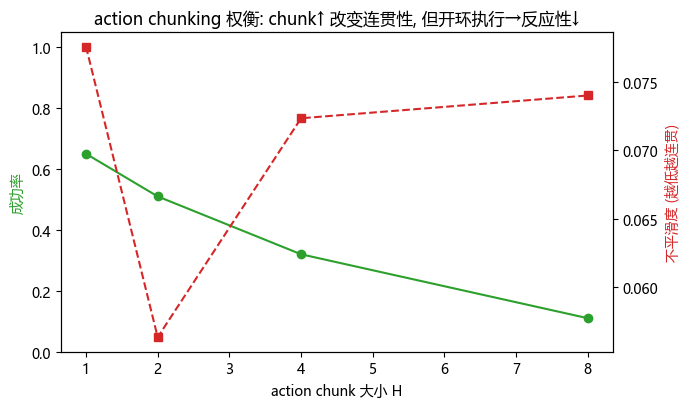

measured: {1: '成功0.65/不平滑0.08', 2: '成功0.51/不平滑0.06', 4: '成功0.32/不平滑0.07', 8: '成功0.11/不平滑0.07'}
→ 本玩具需要闭环纠错, chunk 越大开环越久→成功率下降 (反应性代价)。


In [4]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
chs=[r[0] for r in rows]; srs=[r[1] for r in rows]; sms=[r[3] for r in rows]
fig, ax1 = plt.subplots(figsize=(7,4.2))
ax1.plot(chs, srs, 'o-', color='C2', label='成功率 (反应性)')
ax1.set_xlabel('action chunk 大小 H'); ax1.set_ylabel('成功率', color='C2'); ax1.set_ylim(0,1.05)
ax2 = ax1.twinx(); ax2.plot(chs, sms, 's--', color='C3', label='轨迹不平滑度')
ax2.set_ylabel('不平滑度 (越低越连贯)', color='C3')
plt.title('action chunking 权衡: chunk↑ 改变连贯性, 但开环执行→反应性↓')
fig.tight_layout(); plt.show()
print('measured:', {r[0]:f'成功{r[1]:.2f}/不平滑{r[3]:.2f}' for r in rows})
print('→ 本玩具需要闭环纠错, chunk 越大开环越久→成功率下降 (反应性代价)。')

## 4. 反思 (11.3 收口)

你量化了 action chunking 的核心权衡。带走:
- **chunking 不是免费的**: 一次预测一段→块内连贯/抗抖/抗延迟, 但**开环执行一长段→失去闭环纠错** (反应性↓)。
- 本玩具需随时纠偏, 所以大 chunk 成功率掉; 真实任务要按「多频繁纠错」折中 (常配 temporal ensembling)。
- chunk 大小是个**任务相关的旋钮** (同扩散步数/CFG, 没有万能值, 该消融, 接 9.4)。

> **M11.3 收口**: 扩散动作头解决多峰(N1); flow-matching 解决快(L3); chunking 解决稳但权衡反应性(N2)。π 动作头 = M10 VLM + M13 flow/扩散 + chunking。
> **交棒 M11.4「robot-data-imitation」**: 动作头怎么训? **模仿学习** (从专家 demo) + 机器人数据 scaling 教训。下一专题 `robot-data-imitation`。